# Testing FASTT-Boosted DiagonalGating

This notebook provides an interactive environment to test the feature selection capabilities of `FASTTBoosted` using the `diagonal` transform. Because this notebook is renderable by documentation generators (such as `mkdocs-jupyter`, `Sphinx`, or `Quarto`), we can include rich outputs and visualizations directly alongside our documentation.

In [1]:
import os
import sys

# Ensure the project root is on the path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import mlflow

from s2t_fs.data.synthetic import generate_synthetic_data
from s2t_fs.models.fastt.fastt_boosted import FASTTBoosted
from s2t_fs.utils.logger import custom_logger as logger

/opt/anaconda3/envs/s2t-fs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthetic Data Generation

We generate a synthetic dataset with exactly **5 informative** features and **25 noise** features. Our goal is to ensure the `DiagonalGating` algorithm learns to ignore the 25 noisy features while assigning high importance to the informative ones.

In [2]:
data_params = {
    "n_samples": 4000,
    "n_informative": 5,
    "n_noise": 25,
    "n_experts": 3,
    "test_size": 0.2,
    "seed": 42
}

X_train, Y_train, X_test, Y_test, stats = generate_synthetic_data(data_params)
print(f"Data generated: {stats['num_total_rows']} rows, {stats['num_features']} total features")

Generating synthetic data: 4000 samples, 30 features (5 informative, 25 noise), 3 experts
Synthetic data ready. Train: 3200, Test: 800, Oracle WER: 0.3710


Data generated: 4000 rows, 30 total features


## 2. Model Training

We instantiate `FASTTBoosted` with the `diagonal` gating transform. The combination of L1 and L2 regularization (`lambda1=0.05` and `lambda2=0.01`) acts as an Elastic Net penalty that encourages sparsity in the gating weights, aggressively zeroing out uninformative dimensions during training.

In [3]:
model = FASTTBoosted(
    num_rounds=3,
    transform_type="diagonal",
    transform_kwargs={"lambda1": 0.05, "lambda2": 0.01},
    num_trees=10,
    depth=3,
    lmbda=0.1,
    lr=1e-2,
    weight_decay=1e-4,
    epochs=100,
    patience=20,
    random_state=42,
    batch_size=128
)

model.fit(X_train, Y_train)

,num_rounds,3
,transform_type,'diagonal'
,transform_kwargs,"{'lambda1': 0.05, 'lambda2': 0.01}"
,num_trees,10
,depth,3
,lmbda,0.1
,lr,0.01
,weight_decay,0.0001
,batch_size,128
,epochs,100
,patience,20


## 3. Visualization of Gating Weights

By evaluating the learned gating vectors $q$ for each boosting round, we can physically inspect which features the model selected. 

We should observe distinct magnitude spikes for the first 5 features (informative) and a flat baseline near zero for the remaining 25 features.

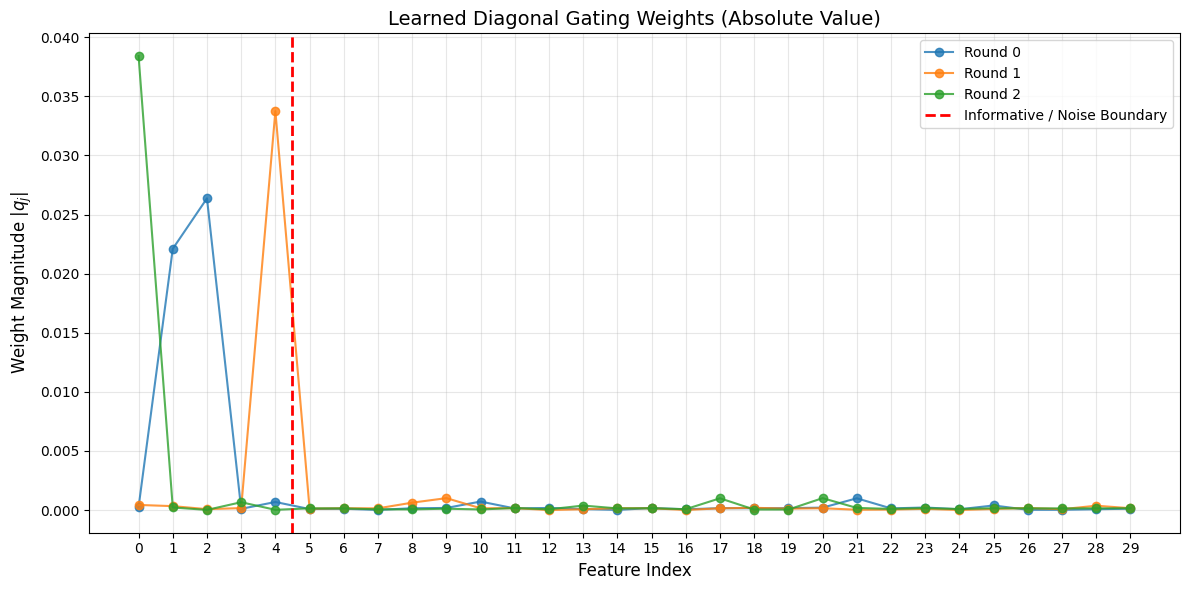

In [4]:
gating_weights = model.get_gating_weights()

plt.figure(figsize=(12, 6))

for round_idx, round_weights in enumerate(gating_weights):
    plt.plot(np.abs(round_weights), marker='o', alpha=0.8, label=f'Round {round_idx}')
    
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Informative / Noise Boundary')
plt.title('Learned Diagonal Gating Weights (Absolute Value)', fontsize=14)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Weight Magnitude $|q_j|$', fontsize=12)
plt.xticks(range(30))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()